In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt
import cv2

from tqdm import tqdm

import os
from Dataset.data import DataPath
from Dataset.DataSetLoaders.ChessDataset import ChessDataset

In [2]:
from BoardDetection.BoardDetector_YOLO_Saddle import Bounded_Saddle_Yolo
from BoardDetection.BoardDetector_YOLO_Lattice import main_yolo
from BoardDetection.BoardDetector_Saddle import BoardDetection_saddle
from PIL import Image
from torchvision import transforms

BE = Bounded_Saddle_Yolo.BoardExtractor()

# replace with method being tested
def extractCorners_yolo_saddle(img: torch.Tensor) -> torch.Tensor: # [4,2]
    BE.set_img(img)
    quad, conf = BE.extract_board()
    quad = torch.tensor(quad, dtype=torch.float32)

    return quad

def extractCorners_yolo_lines(img: torch.Tensor) -> torch.Tensor: # [4,2]
    M, corners, mask_fit, error = main_yolo.detect_board_img(img)
    return corners

def extractCorners_saddle(img: torch.Tensor) -> torch.Tensor: # [4,2]
    corners = BoardDetection_saddle.detect(img)
    return torch.tensor(corners, dtype=torch.float32)

In [3]:
def get_mask(corners: torch.Tensor, size: tuple[int, int]) -> torch.Tensor:
    mask = np.zeros(size)
    mask = cv2.fillPoly(mask, [corners.numpy().astype(np.int32)], 1)
    return torch.tensor(mask, dtype=torch.float32)

In [4]:
def get_acc(corners_prime: torch.Tensor, corners: torch.Tensor, img_shape: tuple[int, int]) -> float:
    # IOU
    mask_prime = get_mask(corners_prime, img_shape)
    mask = get_mask(corners, img_shape)
    intersection = torch.sum(mask * mask_prime)
    union = torch.sum((mask + mask_prime) > 0)

    tl_idx = ((corners_prime - corners[[0]])**2).mean(dim=1).argmin()

    tmp = [tl_idx%4, (tl_idx+1)%4, (tl_idx+2)%4, (tl_idx+3)%4]
    tmp = [i.item() for i in tmp]
    mse_acc = ((corners - corners_prime[tmp]).reshape(-1)**2).mean()
    return (intersection / union).item(), mse_acc

In [5]:
def plot_acc(img, y_prime, y):
    mask = get_mask(y, img.shape[:2])
    mask_prime = get_mask(y_prime, img.shape[:2])
    plt.imshow(img, cmap='gray');
    plt.imshow(mask, alpha=mask*.5, cmap='Blues');
    plt.imshow(mask_prime, alpha=mask_prime*.5, cmap='Reds');
    plt.scatter(y_prime[:,0], y_prime[:,1]);

    acc = get_acc(y_prime[:4], y, img.shape)
    return acc

In [6]:
dataset = ChessDataset(
    "/mnt/D/University/Thesis_Dataset/Dataset",
    target_transforms=lambda x: x["corners"],
    config={
        "img_size": (640,640),
    }
)
len(dataset)

389

tensor([[134.,  98.],
        [484.,  99.],
        [600., 543.],
        [ 10., 550.]])


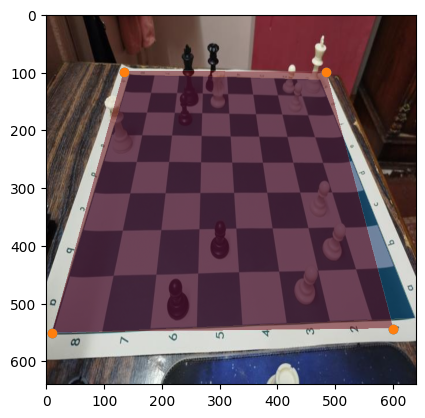

In [7]:
# Github Saddle Points

img, y = dataset[340]

y_prime = extractCorners_yolo_saddle(img)
print(y_prime)

# --------------------------------------

plot_acc(img.permute(1,2,0), y_prime, y)
plt.scatter(y_prime[:,0], y_prime[:,1]);

In [8]:
accs = []

for i in tqdm(range(len(dataset))):
    img,y = dataset[i]
    y_prime = extractCorners_yolo_saddle(img)

    acc = get_acc(y_prime, y, img.shape)
    accs.append(acc)

# Time: 1m 20s
# print(sum(accs)/len(accs), min(accs), max(accs))
accs1 = [item[0] for item in accs]
accs2 = [item[1] for item in accs]
print(sum(accs1)/len(accs1), min(accs1), max(accs1), sum(accs2)/len(accs2), min(accs2), max(accs2))

100%|██████████| 389/389 [00:43<00:00,  9.04it/s]

0.9757821323939032 0.9034482836723328 0.9984076619148254 tensor(134.3084) tensor(30.6111) tensor(769.0553)


In [18]:
dataset = ChessDataset(
    "/mnt/D/University/Thesis_Dataset/Dataset",
    target_transforms=lambda x: x["corners"],
    config={
        "img_size": (500,500),
        # "gray": True,
        # "is_int": True,
    }
)
len(dataset)

389

In [19]:
# Github Saddle Points

img, y = dataset[0]

y_prime = extractCorners_saddle(img)

plot_acc(img.permute(1,2,0), y_prime, y)

RuntimeError: Chessboard detection failed: Unsupported number of channels: 500

In [20]:
accs = []

for i in tqdm(range(len(dataset))):
# for i in tqdm(range(10)):
    if i == 32:
        continue
    try:
        img,y = dataset[i]
        y_prime = extractCorners_saddle(img)

        acc = get_acc(y_prime, y, (3,*img.shape))
        accs.append(acc)
    except Exception as e:
        accs.append(0)
        print(e)

# Time: 9m 26s
# print(sum(accs)/len(accs), min(accs), max(accs))
accs1 = [item[0] for item in accs]
accs2 = [item[1] for item in accs]
print(sum(accs1)/len(accs1), min(accs1), max(accs1), sum(accs2)/len(accs2), min(accs2), max(accs2))

  6%|▌         | 23/389 [00:00<00:03, 114.77it/s]

Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection fail

 13%|█▎        | 49/389 [00:00<00:02, 121.80it/s]

Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection fail

 16%|█▌        | 62/389 [00:00<00:02, 117.78it/s]

...

 95%|█████████▌| 371/389 [00:03<00:00, 118.25it/s]

Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection fail

100%|██████████| 389/389 [00:04<00:00, 96.19it/s] 

Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500
Chessboard detection failed: Unsupported number of channels: 500


TypeError: 'int' object is not subscriptable